# <font color = 'indianred'>**Multilabel Classification of Emotions Dataset using GEMMA** </font>

**Objective:**<br>
Demonstrate inference and evaluation of a base Gemma-2-2B model for a multilabel text classification task on the StackExchange dataset using vLLM.
The notebook shows how to: <br>

1. Perform guided (constrained) decoding via JSON schema enforcement to produce structured label outputs.<br>
2. Generate predictions with vLLM’s high-performance inference engine.<br>
3. Evaluate results using multilabel metrics (macro F1) and visualize performance through confusion matrices.<br>
4. Log validation and test performance to Weights & Biases (WandB) for experiment tracking.<br>

**Plan**

1. Set Environment
2. Load Dataset
3. Download Model and setup vLLM
4. Setup WandB
5. Validation
6. Performance on Test Set
























# <font color = 'indianred'> **1. Setting up the Environment** </font>



In [2]:
if 'google.colab' in str(get_ipython()):
  !pip install numpy -U -qq
  !pip install transformers evaluate wandb datasets accelerate trl peft bitsandbytes -U -qq
  !pip install vllm==0.11.2
  !pip uninstall tensorflow -y -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 133.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.5 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

ERROR: Operation cancelled by user
^C


 <Font size = 5 color = 'indianred'>**Restart the session before moving onto next cell**
> Runtime- Restart Session

<font color = 'indianred'> *Load Libraries* </font>

In [35]:
import os
os.environ['VLLM_USE_V1'] = '1' # this should be done befre any other import

import torch
import torch.nn as nn
from vllm import LLM, SamplingParams
from vllm.lora.request import LoRARequest
from vllm.sampling_params import GuidedDecodingParams

In [36]:
# standard pythgion libraries
from pathlib import Path

from typing import Dict, List, Union, Optional, Tuple
from tqdm import tqdm
import json
import os
import sys

# Data Science librraies
import numpy as np
import pandas as pd
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from pprint import pprint

# Pytorch
import torch

# Huggingface Librraies
import evaluate
from datasets import load_dataset

from huggingface_hub import login

# Logging and secrets
import wandb
from google.colab import userdata
from huggingface_hub import login, HfApi, create_repo

In [37]:
sys.path

['/usr/local/lib/python3.12/dist-packages/ray/thirdparty_files',
 '/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/nvidia_cutlass_dsl/python_packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython',
 '/tmp/tmp4cbew4kn',
 '/content/drive/My Drive/Fall_2025_Notes/NLP/HW 6/0_shared_utils',
 '/usr/local/lib/python3.12/dist-packages/setuptools/_vendor',
 '/root/.cache/huggingface/modules',
 '/content/drive/My Drive/Fall_2025_Notes/NLP/HW 6/0_shared_utils',
 '/content/drive/My Drive/Fall_2025_Notes/NLP/HW 6/0_shared_utils']

In [39]:
from pathlib import Path
# Determine the storage location based on the execution environment
# If running on Google Colab, use Google Drive as storage
if 'google.colab' in str(get_ipython()):
    from google.colab import drive  # Import Google Drive mounting utility
    drive.mount('/content/drive')  # Mount Google Drive

    # Set base folder path for storing data on Google Drive
    base_folder= Path('/content/drive/My Drive/Fall_2025_Notes/NLP/HW 6')
    project_folder = Path('/content/drive/My Drive/Fall_2025_Notes/NLP/HW 6')
# If running locally, specify a different path
else:
    # Set base folder path for storing data on local machine
    base_folder= Path('/home/')
    project_folder = Path('/home/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
wandb_api_key = userdata.get('WANDB_API_KEY')
hf_token = userdata.get('HF_TOKEN')

In [47]:
if hf_token:
    # Log in to Hugging Face
    login(token=hf_token)
    print("Successfully logged in to Hugging Face!")
else:
    print("Hugging Face token not found in notebook secrets.")

Successfully logged in to Hugging Face!


In [48]:
if wandb_api_key:
  wandb.login(key=wandb_api_key)
  print("Successfully logged in to WANDB!")
else:
    print("WANDB key not found in notebook secrets.")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


Successfully logged in to WANDB!


# <font color = 'indianred'> **2. Load Data set**
    


In [49]:
# Students can set the data_folder and model_folder paths based on their base_folder setup.
data_folder = base_folder/'datasets'
model_folder = project_folder/'models'
model_folder.mkdir(exist_ok=True, parents = True)
data_folder.mkdir(exist_ok=True, parents = True)

In [50]:
# Load train/test CSVs
train_path = data_folder / "train.csv"
test_path  = data_folder / "test.csv"

train_df = pd.read_csv(train_path)
kaggle_test_df  = pd.read_csv(test_path)

TEXT_COL = "Tweet"
label_cols = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
label_names = label_cols  # used in prompt text

# Ensure label columns are numeric in train set
train_df[label_cols] = train_df[label_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

# Train/Validation split
SEED = 42
train_val_df, _heldout_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=SEED,
    shuffle=True
)

_train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.15 / 0.85,
    random_state=SEED,
    shuffle=True
)

def build_prompt(text: str) -> str:
    return (
        "Return ONLY valid JSON. No explanation. "
        f"Keys must be exactly: {label_names}. "
        f"### TEXT: {text.strip()} ### LABEL:"
    )

val_prompts = [build_prompt(t) for t in val_df[TEXT_COL].astype(str).tolist()]
test_prompts = [build_prompt(t) for t in _heldout_df[TEXT_COL].astype(str).tolist()]
kaggle_test_prompts = [build_prompt(t) for t in kaggle_test_df[TEXT_COL].astype(str).tolist()]

# Ground-truth labels for validation/test
val_labels = val_df[label_cols].values.tolist()
test_labels = _heldout_df[label_cols].values.tolist()

def build_label_string_from_row(row) -> str:
    labels = [lbl for lbl in label_cols if row[lbl] == 1]
    return json.dumps(labels)

val_true_label_strings = val_df.apply(build_label_string_from_row, axis=1).tolist()
test_true_label_strings = _heldout_df.apply(build_label_string_from_row, axis=1).tolist()


print("Validation prompts:", len(val_prompts))
print("Held-out test prompts:", len(test_prompts))
print("Kaggle test prompts:", len(kaggle_test_prompts))
print("\nExample validation record:")
pprint({"prompt": val_prompts[0], "labels": val_labels[0]})


Validation prompts: 1159
Held-out test prompts: 1159
Kaggle test prompts: 3259

Example validation record:
{'labels': [1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
 'prompt': 'Return ONLY valid JSON. No explanation. Keys must be exactly: '
           "['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', "
           "'optimism', 'pessimism', 'sadness', 'surprise', 'trust']. ### "
           'TEXT: And it pisses me off more they killed people who '
           "surrendered. Hands up and all. If hands visible you shouldn't be "
           'fearing for your life ### LABEL:'}


#  <font color = 'indianred'> **3. Download Model and setup vLLM**

In [51]:
torch.cuda.empty_cache()

# Base model used during Part B training
BASE_MODEL = "google/gemma-2-2b-it"

# Path to my LoRA adapter from PartB_Training_Language_Head.ipynb
ADAPTER_ROOT = Path("/content/drive/My Drive/Fall_2025_Notes/NLP/HW 6/models/best_adapter_export")

def resolve_lora_adapter_path(adapter_root: Path) -> str:
    # If adapter files are directly in adapter_root, use it.
    if (adapter_root / "adapter_config.json").exists():
        return str(adapter_root)

    # Otherwise, pick the latest checkpoint-* folder that contains adapter_config.json
    ckpts = sorted(adapter_root.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[-1]) if p.name.split("-")[-1].isdigit() else -1)
    for p in reversed(ckpts):
        if (p / "adapter_config.json").exists():
            return str(p)

    raise FileNotFoundError(
        f"Could not find adapter_config.json in {adapter_root} or any checkpoint-* subfolder. "
        "Update ADAPTER_ROOT to the folder that contains your LoRA adapter files."
    )

LORA_ADAPTER = resolve_lora_adapter_path(ADAPTER_ROOT)
print("Using LoRA adapter:", LORA_ADAPTER)


Using LoRA adapter: /content/drive/My Drive/Fall_2025_Notes/NLP/HW 6/models/best_adapter_export


In [14]:
llm = LLM(
    model=BASE_MODEL,
    dtype=torch.bfloat16,
    trust_remote_code=True,
    quantization="bitsandbytes",
    enable_lora=True,
    max_lora_rank=128,
    gpu_memory_utilization=0.6,
    guided_decoding_backend="outlines",
)


INFO 12-13 06:38:42 [utils.py:253] non-default args: {'trust_remote_code': True, 'dtype': torch.bfloat16, 'gpu_memory_utilization': 0.6, 'disable_log_stats': True, 'quantization': 'bitsandbytes', 'enable_lora': True, 'max_lora_rank': 128, 'guided_decoding_backend': 'outlines', 'model': 'google/gemma-2-2b-it'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


INFO 12-13 06:38:44 [model.py:631] Resolved architecture: Gemma2ForCausalLM
INFO 12-13 06:38:44 [model.py:1745] Using max model len 8192
INFO 12-13 06:38:44 [scheduler.py:216] Chunked prefill is enabled with max_num_batched_tokens=8192.
WARNING 12-13 06:38:47 [system_utils.py:103] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
INFO 12-13 06:40:15 [llm.py:352] Supported tasks: ['generate']


In [ ]:
# lora_request = LoRARequest(
#     lora_name="emotion_classifier", #just changed the lora name to match
#     lora_int_id=1,
#     lora_path=LORA_ADAPTER
# )

# array_schema = {
#     "type": "array",
#     "items": {
#         "type": "string",
#         "enum": ["anger", "anticipation", "disgust", "fear", "joy", "love", "optimism", "pessimism", "sadness", "surprise", "trust"]
#     },
#     "minItems": 1,
#     "maxItems": 11,
# }

# guided_decoding = GuidedDecodingParams(
#     json=array_schema,
#     backend="outlines"
# )

# sampling_params = SamplingParams(
#     temperature=0,
#     max_tokens=20,
#     guided_decoding=guided_decoding,
# )


In [15]:
lora_request = LoRARequest(
    lora_name="emotion_classifier", #just changed the lora name to match
    lora_int_id=1,
    lora_path=LORA_ADAPTER
)

#Had to change array to object schema because of issues i faced later
object_schema = {
    "type": "object",
    "properties": {lbl: {"type": "integer", "enum": [0, 1]} for lbl in label_cols},
    "required": label_cols,
    "additionalProperties": False
}

#Modified the decoding to match object_schema instead of array_schema
guided_decoding = GuidedDecodingParams(
    json=object_schema,
    backend="outlines"
)


sampling_params = SamplingParams(
    temperature=0,
    max_tokens=128, #increased max_tokens to 128
    guided_decoding=guided_decoding,
)


/tmp/ipython-input-402502120.py:22: DeprecationWarning: guided_decoding is deprecated. This will be removed in v0.12.0 or v1.0.0, which ever is soonest. Please use structured_outputs instead.
  sampling_params = SamplingParams(


# <font color = 'indianred'> **4. Setup WandB**</font>

In [16]:
%env WANDB_PROJECT = multilabel_stack
# Resume existing run
run = wandb.init(
    project="multilabel_PartBNotebook1_2025",
    entity="stevenqcly-the-university-of-texas-at-dallas",
    id="2wvlualv",
    resume="must"
)

env: WANDB_PROJECT=multilabel_stack


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


#<font color = 'indianred'> **5. Utility Functions**

In [17]:
def generate_predictions_batch(prompts: List[str],
                               llm: LLM,
                               sampling_params: SamplingParams,
                               lora_request: LoRARequest,
                               batch_size: int = 64) -> List[List[str]]:
    """
    Generate predictions for a list of prompts using vLLM batch inference.

    Args:
        prompts: List of input prompts
        llm: vLLM model instance
        sampling_params: Sampling parameters for generation
        lora_request: LoRA adapter request
        batch_size: Batch size for inference

    Returns:
        List of predicted labels (as lists of strings)
    """
    predictions = []

    for i in tqdm(range(0, len(prompts), batch_size), desc="Generating predictions"):
        batch = prompts[i:i+batch_size]

        outputs = llm.generate(
            batch,
            sampling_params,
            lora_request=lora_request
        )

        for output in outputs:
          pred_dict = json.loads(output.outputs[0].text)

          # Convert dict -> list of labels (same output type as before)
          pred_labels = [lbl for lbl in class_names if int(pred_dict.get(lbl, 0)) == 1]
          predictions.append(pred_labels)

    print(f"Processed {len(predictions)}/{len(prompts)} prompts")
    return predictions


In [18]:
def parse_label_string(label_str: str) -> List[str]:
    """Parse label string to list of labels."""
    try:
        return json.loads(label_str.strip())
    except:
        return []


In [19]:
f1 = evaluate.load('f1','multilabel')
def compute_metrics( labels, preds):
  f1_macro = f1.compute(predictions=preds, references=labels, average='macro')
  return {'f1_macro':f1_macro['f1'],}

In [20]:
def evaluate_multilabel_predictions(true_labels: Union[List[str], List[List[str]]],
                                     predictions: List[List[str]],
                                     class_names: List[str],
                                     split_name: str = "valid",
                                     log_to_wandb: bool = True,
                                     show_confusion_matrix: bool = True) -> Dict:
    """
    Evaluate multilabel predictions and optionally log to wandb.

    Args:
        true_labels: List of label strings OR list of label lists
        predictions: List of predicted label lists
        class_names: List of all possible class names
        split_name: Name of the split (for wandb logging)
        log_to_wandb: Whether to log metrics to wandb
        show_confusion_matrix: Whether to display confusion matrix

    Returns:
        Dictionary containing evaluation metrics
    """
    # Parse true labels only if they are strings
    if len(true_labels) > 0 and isinstance(true_labels[0], str):
        parsed_labels = [parse_label_string(label) for label in true_labels]
        print(f"Parsed string labels to lists")
    else:
        parsed_labels = true_labels
        print(f"Labels already in list format")

    # Initialize MultiLabelBinarizer
    mlb = MultiLabelBinarizer(classes=class_names)
    mlb.fit([class_names])  # Fit with all possible classes

    # Transform to binary format
    labels_binary = mlb.transform(parsed_labels)
    predictions_binary = mlb.transform(predictions)

    # Print samples and shapes
    print(f"\n{'='*60}")
    print(f"{split_name.upper()} SET EVALUATION")
    print(f"{'='*60}")
    print(f"Sample true labels: {parsed_labels[:3]}")
    print(f"Sample predictions: {predictions[:3]}")
    print(f"\nBinary shapes:")
    print(f"  Labels:      {labels_binary.shape}")
    print(f"  Predictions: {predictions_binary.shape}")

    # Compute metrics
    metrics = compute_metrics(labels_binary, predictions_binary)
    print(f"\nMetrics:")
    print(f"  F1 Macro: {metrics['f1_macro']:.4f}")

    # Log to wandb
    if log_to_wandb:
        wandb.log({f"{split_name}_f1_macro": metrics["f1_macro"]})
        print(f"  ✓ Logged to wandb")

    # Display confusion matrix
    if show_confusion_matrix:
        print(f"\nConfusion Matrix:")
        multilabel_evaluation(
            y_true=labels_binary,
            y_pred=predictions_binary,
            class_names=class_names,
            figsize=(12, 8)
        )

    return metrics

#<font color = 'indianred'> **6. Performance on Validation Set**

<font color = 'indianred'> *Evaluate model on Validation Set* </font>


In [21]:
# Define class names (used for both validation and test)
class_names = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']


In [22]:
val_predictions = generate_predictions_batch(
    prompts=val_prompts,
    llm=llm,
    sampling_params=sampling_params,
    lora_request=lora_request,
    batch_size=64
)

Generating predictions:   0%|          | 0/19 [00:00<?, ?it/s]

Adding requests:   0%|          | 0/64 [00:00<?, ?it/s]

WARNING 12-13 06:40:40 [processor.py:246] vLLM has deprecated support for supporting different tokenizers for different LoRAs. By default, vLLM uses base model's tokenizer. If you are using a LoRA with its own tokenizer, consider specifying `--tokenizer [lora_path]` to use the LoRA tokenizer.


Processed prompts:   0%|          | 0/64 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions:   5%|▌         | 1/19 [00:03<01:04,  3.61s/it]

...

Generating predictions:  95%|█████████▍| 18/19 [00:33<00:01,  1.75s/it]

Adding requests:   0%|          | 0/7 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/7 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions: 100%|██████████| 19/19 [00:34<00:00,  1.80s/it]

Processed 1159/1159 prompts


In [23]:
val_predictions[0:5]

[['anger', 'disgust', 'fear', 'pessimism', 'sadness'],
 ['fear'],
 ['fear', 'pessimism', 'sadness'],
 [],
 ['disgust']]

In [53]:
#This whole block of code is the shared_utils py
import gc
import time
import torch
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn

from sklearn.metrics import multilabel_confusion_matrix, precision_score, recall_score, f1_score
def free_gpu_memory():
    """
    Frees up GPU memory after CUDA out-of-memory error in Colab.

    This function performs the following steps:
    1. Deletes all PyTorch objects to clear references.
    2. Calls garbage collection to remove unreferenced objects from memory.
    3. Uses torch.cuda.empty_cache() to release cached GPU memory.
    4. Waits for a moment to ensure memory is fully released.
    """
    try:
        # Delete all torch tensors to free up memory
        for obj in list(locals().values()):
            if torch.is_tensor(obj):
                del obj

        # Collect garbage to release any remaining unused memory
        gc.collect()

        # Empty the CUDA cache to release GPU memory
        torch.cuda.empty_cache()

        # Adding a small delay to allow memory to be fully released
        time.sleep(2)

        print("GPU memory has been freed.")
    except Exception as e:
        print(f"Error while freeing GPU memory: {e}")

def find_linear_layers(model):
    """
    Extracts the unique names of Linear layers from a model.

    Args:
    model (nn.Module): The model from which to extract Linear layer names.

    Returns:
    list: A list of unique names of Linear layers.
    """
    # Convert the model's modules to string
    model_modules = str(model.modules)
    # Pattern to extract names of Linear layers
    pattern = r'\((\w+)\): Linear'
    # Find all occurrences of the pattern
    linear_layer_names = re.findall(pattern, model_modules)
    print(linear_layer_names)
    # Get unique names using a set, then convert back to list
    target_modules = list(set(linear_layer_names))
    return target_modules

def verify_loss_masking_detailed(tokenizer,trainer, num_samples=3):
    """
    Verify that labels are properly masked for prompt tokens.
    Shows exact tokens where loss is calculated.
    """
    # Get a sample batch
    dataloader = trainer.get_train_dataloader()
    batch = next(iter(dataloader))

    for i in range(min(num_samples, len(batch['input_ids']))):
        input_ids = batch['input_ids'][i]
        labels = batch['labels'][i]

        print(f"\n{'='*80}")
        print(f"Sample {i+1}:")
        print(f"{'='*80}")

        # Decode the full sequence
        full_text = tokenizer.decode(input_ids, skip_special_tokens=False)
        print(f"\nFull text:\n{full_text}")

        # Find where labels start (not -100)
        label_start_idx = (labels != -100).nonzero(as_tuple=True)[0]

        if len(label_start_idx) > 0:
            first_label_idx = label_start_idx[0].item()

            # Decode prompt (masked part)
            prompt_ids = input_ids[:first_label_idx]
            prompt_text = tokenizer.decode(prompt_ids, skip_special_tokens=False)

            # Decode completion (unmasked part)
            completion_ids = input_ids[first_label_idx:]
            completion_text = tokenizer.decode(completion_ids, skip_special_tokens=False)

            print(f"\n{'─'*80}")
            print(f"PROMPT (masked with -100):\n{prompt_text}")
            print(f"\n{'─'*80}")
            print(f"COMPLETION (loss calculated here):\n{completion_text}")
            print(f"\n{'─'*80}")

            # Show label statistics
            num_masked = (labels == -100).sum().item()
            num_unmasked = (labels != -100).sum().item()
            print(f"\nLabel Statistics:")
            print(f"  Masked tokens (prompt): {num_masked}")
            print(f"  Unmasked tokens (completion): {num_unmasked}")
            print(f"  Total tokens: {len(labels)}")
            print(f"  Percentage of tokens used for loss: {num_unmasked/len(labels)*100:.2f}%")

            # ===== NEW: Show exact tokens where loss is calculated =====
            print(f"\n{'='*80}")
            print("EXACT TOKENS WHERE LOSS IS CALCULATED:")
            print(f"{'='*80}")
            print(f"{'Index':<8} {'Token ID':<12} {'Token':<40} {'Label ID':<12}")
            print(f"{'-'*80}")

            for idx in range(len(input_ids)):
                token_id = input_ids[idx].item()
                label_id = labels[idx].item()

                # Only show tokens where loss is calculated (label != -100)
                if label_id != -100:
                    # Decode individual token
                    token_text = tokenizer.decode([token_id], skip_special_tokens=False)
                    # Show what the model should predict (the label)
                    label_text = tokenizer.decode([label_id], skip_special_tokens=False)

                    print(f"{idx:<8} {token_id:<12} {repr(token_text):<40} {label_id:<12}")

            print(f"{'-'*80}")

            # Additional: Show first few masked tokens for comparison
            print(f"\n{'='*80}")
            print("FIRST 10 MASKED TOKENS (for comparison - NO loss calculated):")
            print(f"{'='*80}")
            print(f"{'Index':<8} {'Token ID':<12} {'Token':<40} {'Label':<12}")
            print(f"{'-'*80}")

            masked_count = 0
            for idx in range(len(input_ids)):
                token_id = input_ids[idx].item()
                label_id = labels[idx].item()

                if label_id == -100:
                    token_text = tokenizer.decode([token_id], skip_special_tokens=False)
                    print(f"{idx:<8} {token_id:<12} {repr(token_text):<40} {'-100':<12}")
                    masked_count += 1
                    if masked_count >= 10:
                        break

            print(f"{'-'*80}")

        else:
            print("WARNING: All labels are masked! No loss will be calculated.")

    print(f"\n{'='*80}\n")

def multilabel_evaluation(y_true, y_pred, class_names=None, figsize=(12, 8)):
    """
    Generate comprehensive evaluation visualizations for multilabel classification results.

    Parameters:
    -----------
    y_true : array-like
        True labels (n_samples, n_classes)
    y_pred : array-like
        Predicted labels (n_samples, n_classes)
    class_names : list, optional
        List of class names for better visualization
    figsize : tuple, optional
        Base figure size for plots (width, height)

    Returns:
    --------
    dict
        Dictionary containing the computed metrics for each class
    """
    # Validate inputs
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape")

    # Generate class names if not provided
    if class_names is None:
        class_names = [f'Class {i}' for i in range(y_true.shape[1])]

    # Calculate confusion matrices
    mcm = multilabel_confusion_matrix(y_true, y_pred)

    # 1. Individual Confusion Matrix Heatmaps
    n_classes = len(class_names)
    n_cols = min(3, n_classes)
    n_rows = (n_classes + n_cols - 1) // n_cols

    plt.figure(figsize=(figsize[0], figsize[1] * n_rows/2))
    for idx, matrix in enumerate(mcm):
        plt.subplot(n_rows, n_cols, idx + 1)
        sns.heatmap(matrix, annot=True, fmt='g', cmap='Blues',
                    xticklabels=['Pred Neg', 'Pred Pos'],
                    yticklabels=['True Neg', 'True Pos'])
        plt.title(f'{class_names[idx]}')
    plt.tight_layout()
    plt.show()

    # 2. Calculate and plot aggregate metrics
    metrics = {
        'Precision': precision_score(y_true, y_pred, average=None),
        'Recall': recall_score(y_true, y_pred, average=None),
        'F1-Score': f1_score(y_true, y_pred, average=None)
    }

    metrics_df = pd.DataFrame(metrics, index=class_names)

    # Metrics Heatmap
    plt.figure(figsize=(figsize[0]/1.5, figsize[1]/1.5))
    sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='Blues')
    plt.title('Performance Metrics by Class')
    plt.tight_layout()
    plt.show()

    # 3. Metrics Histogram
    plt.figure(figsize=(figsize[0], figsize[1]/1.5))
    metrics_df.plot(kind='bar', width=0.8)
    plt.xlabel('Classes')
    plt.ylabel('Score')
    plt.title('Precision, Recall, and F1-Score by Class')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 4. Calculate and return summary statistics
    summary_stats = {
        'macro_avg': {
            'precision': np.mean(metrics['Precision']),
            'recall': np.mean(metrics['Recall']),
            'f1': np.mean(metrics['F1-Score'])
        },
        'per_class': metrics_df.to_dict()
    }

    return summary_stats

def get_appropriate_dtype():
    if torch.cuda.is_available() and torch.cuda.get_device_capability(0) >= (8, 0):
        return torch.bfloat16
    return torch.float16

Parsed string labels to lists

VALID SET EVALUATION
Sample true labels: [['anger', 'disgust', 'fear'], ['disgust', 'fear'], ['fear', 'sadness']]
Sample predictions: [['anger', 'disgust', 'fear', 'pessimism', 'sadness'], ['fear'], ['fear', 'pessimism', 'sadness']]

Binary shapes:
  Labels:      (1159, 11)
  Predictions: (1159, 11)

Metrics:
  F1 Macro: 0.4708
  ✓ Logged to wandb

Confusion Matrix:


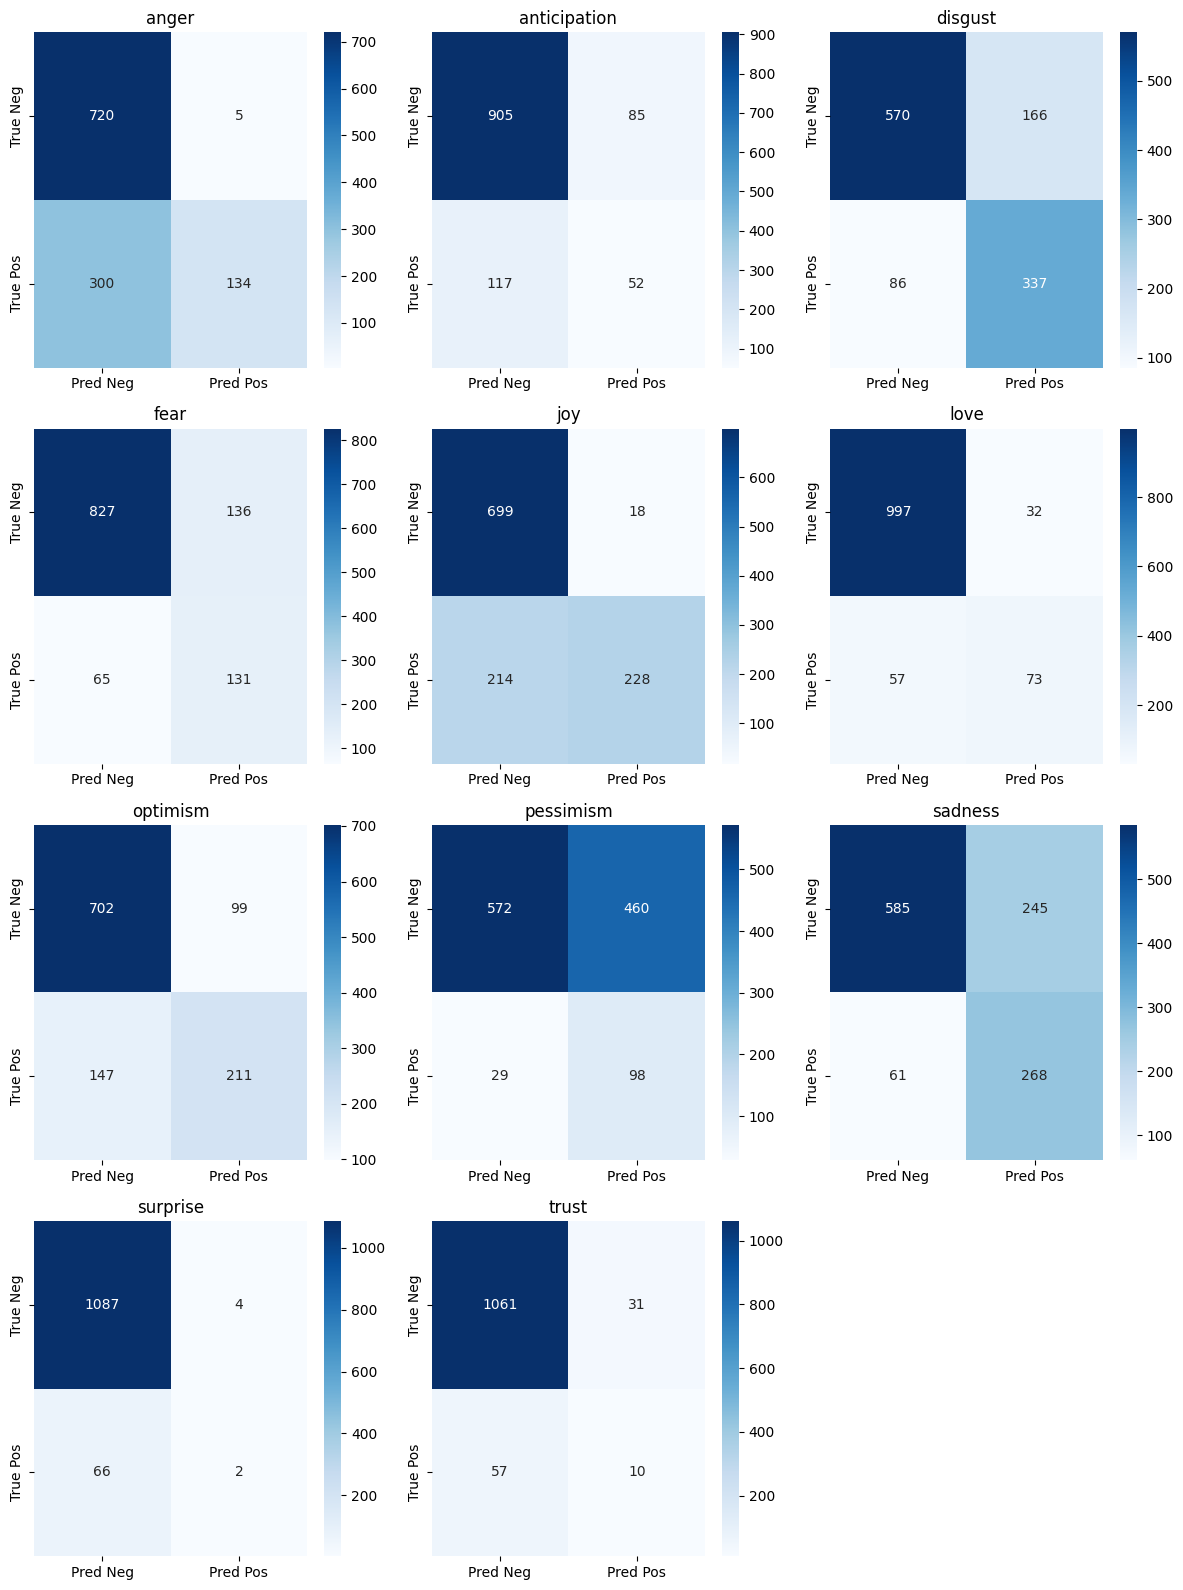

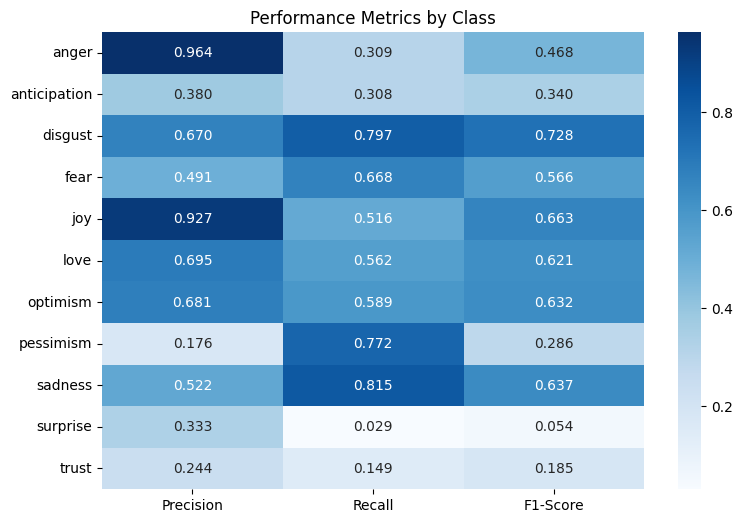

<Figure size 1200x533.333 with 0 Axes>

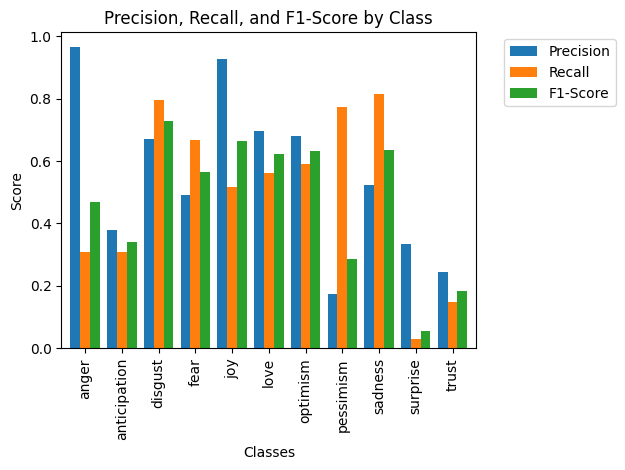

{'f1_macro': 0.47082487164759057}

In [54]:
# Evaluate on validation split
valid_metrics = evaluate_multilabel_predictions(
    true_labels=val_true_label_strings,
    predictions=val_predictions,
    class_names=class_names,
    split_name="valid",
    log_to_wandb=True,
    show_confusion_matrix=True
)

valid_metrics


#  <font color = 'indianred'> **7. Performance on Test Set** </font>
For test set evaluation, we will perfrom following steps:



In [55]:
# Generate predictions
test_predictions = generate_predictions_batch(
    prompts=test_prompts,
    llm=llm,
    sampling_params=sampling_params,
    lora_request=lora_request,
    batch_size=128  # Can use larger batch for test
)

Generating predictions:   0%|          | 0/10 [00:00<?, ?it/s]

Adding requests:   0%|          | 0/128 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/128 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions:  10%|█         | 1/10 [00:02<00:19,  2.12s/it]

Adding requests:   0%|          | 0/128 [00:00<?, ?it/s]

...

Generating predictions:  90%|█████████ | 9/10 [00:19<00:02,  2.12s/it]

Adding requests:   0%|          | 0/7 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/7 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions: 100%|██████████| 10/10 [00:20<00:00,  2.03s/it]

Processed 1159/1159 prompts


Parsed string labels to lists

TEST SET EVALUATION
Sample true labels: [['joy', 'optimism', 'trust'], ['joy', 'optimism'], ['joy', 'love', 'optimism']]
Sample predictions: [['anticipation', 'optimism'], ['joy', 'optimism'], ['joy', 'love', 'optimism', 'trust']]

Binary shapes:
  Labels:      (1159, 11)
  Predictions: (1159, 11)

Metrics:
  F1 Macro: 0.4789
  ✓ Logged to wandb

Confusion Matrix:


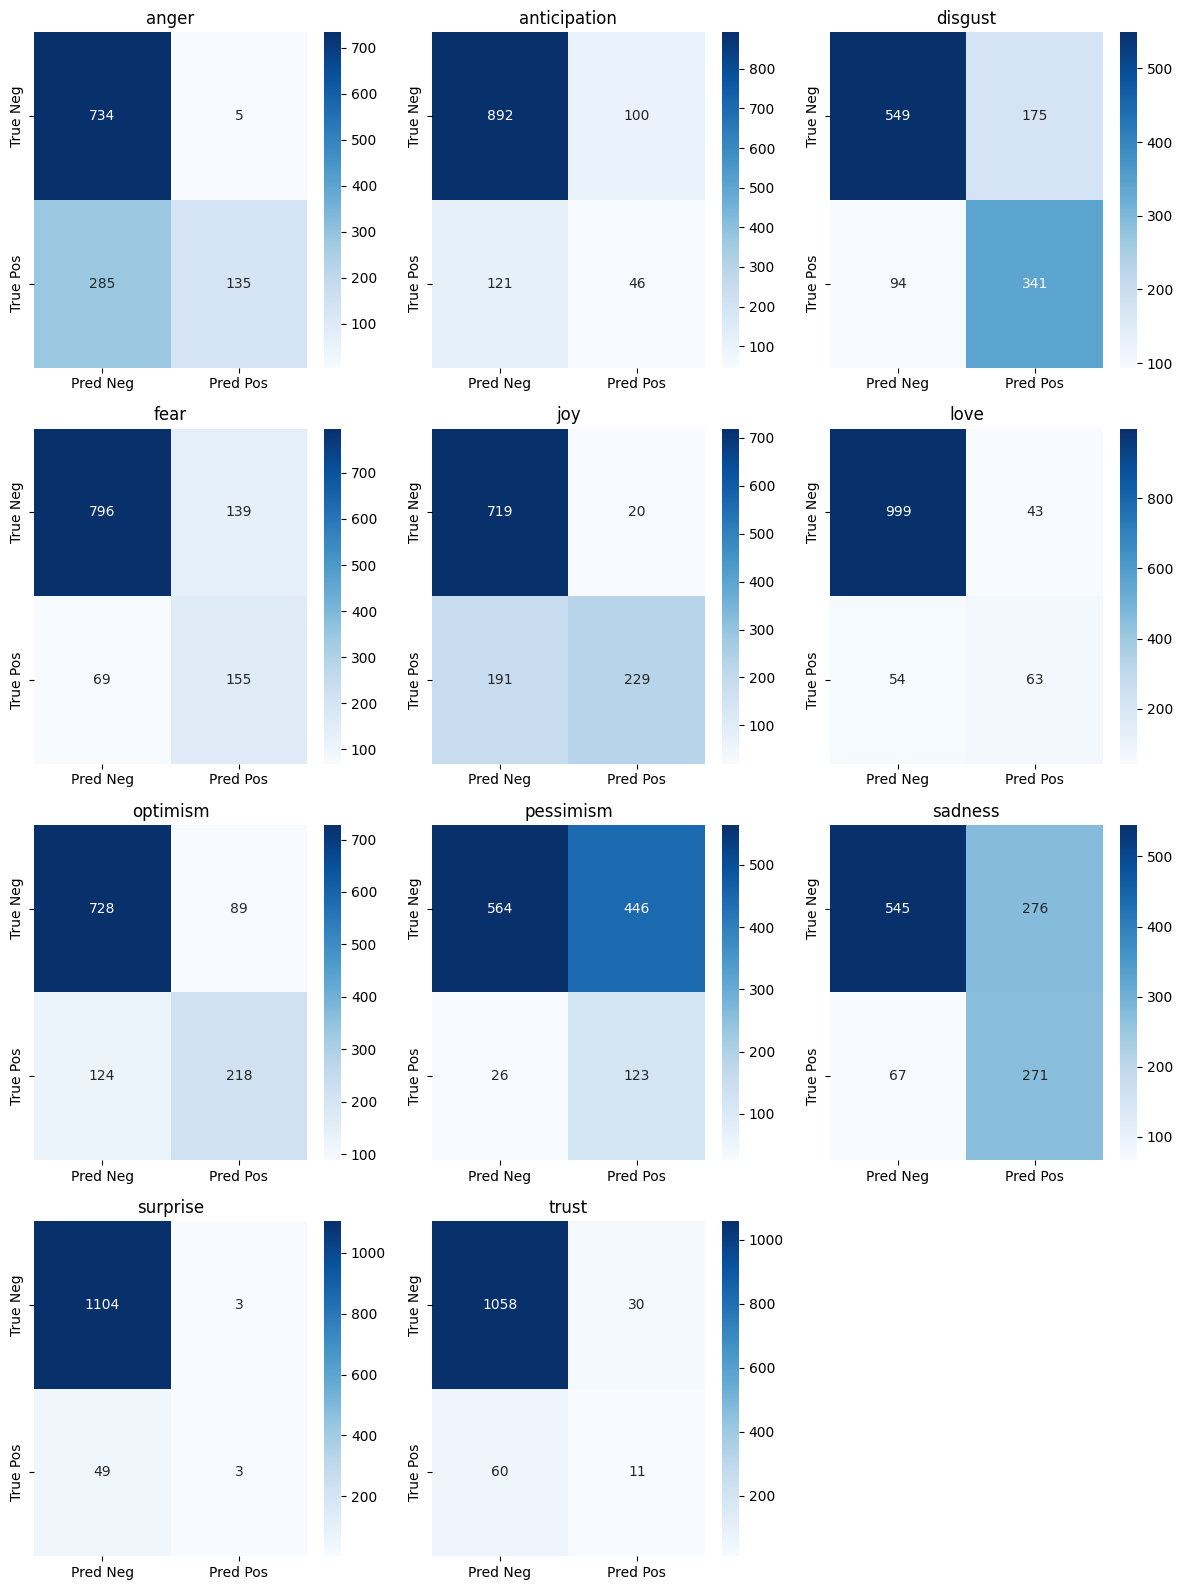

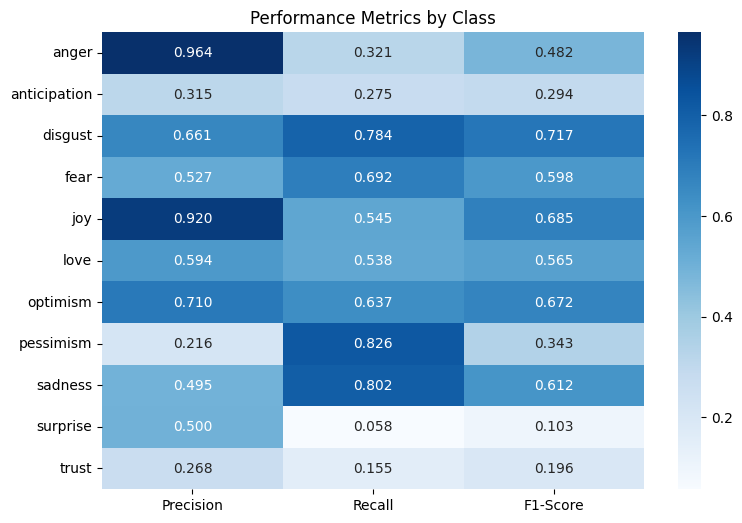

<Figure size 1200x533.333 with 0 Axes>

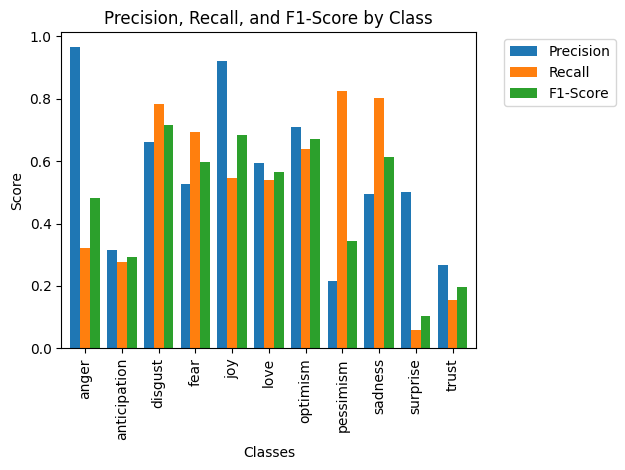

{'f1_macro': 0.47891106477162265}

In [56]:
# Evaluate on held-out test split (created from train.csv)
test_metrics = evaluate_multilabel_predictions(
    true_labels=test_true_label_strings,
    predictions=test_predictions,
    class_names=class_names,
    split_name="test",
    log_to_wandb=True,
    show_confusion_matrix=True
)

test_metrics


#  <font color = 'indianred'> **7B. Kaggle Submission File** </font>
Generate predictions for competition `test.csv` and write a submission file.

In [57]:
# Generate predictions for Kaggle test set (unlabeled)
kaggle_predictions = generate_predictions_batch(
    prompts=kaggle_test_prompts,
    llm=llm,
    sampling_params=sampling_params,
    lora_request=lora_request,
    batch_size=128
)

kaggle_predictions[:3]


Generating predictions:   0%|          | 0/26 [00:00<?, ?it/s]

Adding requests:   0%|          | 0/128 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/128 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions:   4%|▍         | 1/26 [00:02<00:52,  2.11s/it]

Adding requests:   0%|          | 0/128 [00:00<?, ?it/s]

...

Adding requests:   0%|          | 0/59 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/59 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions: 100%|██████████| 26/26 [00:54<00:00,  2.11s/it]

Processed 3259/3259 prompts


[['disgust'],
 ['disgust', 'fear', 'pessimism', 'sadness'],
 ['anger', 'disgust', 'pessimism', 'sadness']]

In [58]:
# Convert predicted label lists -> 0/1 columns and save CSV
def labels_to_binary_row(pred_labels):
    pred_set = set(pred_labels)
    return [1 if lbl in pred_set else 0 for lbl in class_names]

pred_matrix = [labels_to_binary_row(p) for p in kaggle_predictions]

submission_df = pd.DataFrame(pred_matrix, columns=class_names)
submission_df.insert(0, "ID", kaggle_test_df["ID"].values)

submission_path = Path("kaggle_submission_partB_language_head.csv")
submission_df.to_csv(submission_path, index=False)

print("Saved:", submission_path)
submission_df.head()


Saved: kaggle_submission_partB_language_head.csv


,ID,anger,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,2018-01559,0,0,1,0,0,0,0,0,0,0,0
1,2018-03739,0,0,1,1,0,0,0,1,1,0,0
2,2018-00385,1,0,1,0,0,0,0,1,1,0,0
3,2018-03001,0,0,0,1,0,0,0,1,1,0,0
4,2018-01988,0,0,1,1,0,0,0,1,1,0,0


In [68]:
#Download the file
from google.colab import files
files.download("kaggle_submission_partB_language_head.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
# Finish wandb run
wandb.finish()

test_f1_macro,▁
valid_f1_macro,▁▁▁▁
eval/entropy,1.6184
eval/loss,0.37756
eval/mean_token_accuracy,0.85289
eval/num_tokens,941777
eval/runtime,14.0307
eval/samples_per_second,82.605
eval/steps_per_second,5.203
test_f1_macro,0.47891
total_flos,14704798023032832


In [60]:
text = val_prompts[0]
text

"Return ONLY valid JSON. No explanation. Keys must be exactly: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']. ### TEXT: And it pisses me off more they killed people who surrendered. Hands up and all. If hands visible you shouldn't be fearing for your life ### LABEL:"

# <font color = 'indianred'> **8. Inference** </font>

<font color = 'indianred'> *Demonstrate inference on a single text input* </font>


## <font color = 'indianred'> Example 1: Single text *inference* </font>


In [61]:
# Example Single text input
text_1 = "Hello world I am so happy."

In [62]:
def create_prompt_for_single_text(text: str) -> str:
    """Create the EXACT same prompt format used during Part B inference."""
    prompt = (
        "Return ONLY valid JSON. No explanation. "
        "At least ONE label must be 1. "
        f"Keys must be exactly: {label_names}. "
        f"### TEXT: {text.strip()} ### LABEL:"
    )
    return prompt


In [63]:
# Create prompt
prompt_1 = create_prompt_for_single_text(text_1)

In [64]:
prompt_1

"Return ONLY valid JSON. No explanation. At least ONE label must be 1. Keys must be exactly: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']. ### TEXT: Hello world I am so happy. ### LABEL:"

In [65]:
prediction_1 = generate_predictions_batch(
    prompts=[prompt_1],  # Single prompt as a list
    llm=llm,
    sampling_params=sampling_params,
    lora_request=lora_request,
    batch_size=1
)

Generating predictions:   0%|          | 0/1 [00:00<?, ?it/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions: 100%|██████████| 1/1 [00:00<00:00,  1.29it/s]

Processed 1/1 prompts


In [66]:
prediction_1

[['joy', 'optimism']]

## <font color = 'indianred'> Example 2: Multiple custom texts at once </font>


In [67]:
# Multiple texts
custom_texts = [
    "I am super happy",
    "I hope i survive today",
    "NLP is seriously hurting my soul",
    "I am sad"
]

# Create prompts
custom_prompts = [create_prompt_for_single_text(text) for text in custom_texts]

# Predict using existing function
custom_predictions = generate_predictions_batch(
    prompts=custom_prompts,
    llm=llm,
    sampling_params=sampling_params,
    lora_request=lora_request,
    batch_size=64
)

# Display results
print("Batch Inference Results:")
print("="*60)
for text, pred in zip(custom_texts, custom_predictions):
    print(f"\nText: {text}")
    print(f"Predicted Labels: {pred}")
    print("-"*60)

Generating predictions:   0%|          | 0/1 [00:00<?, ?it/s]

Adding requests:   0%|          | 0/4 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/4 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions: 100%|██████████| 1/1 [00:01<00:00,  1.14s/it]

Processed 4/4 prompts
Batch Inference Results:

Text: I am super happy
Predicted Labels: ['joy', 'optimism']
------------------------------------------------------------

Text: I hope i survive today
Predicted Labels: ['fear']
------------------------------------------------------------

Text: NLP is seriously hurting my soul
Predicted Labels: ['anger', 'disgust', 'pessimism', 'sadness']
------------------------------------------------------------

Text: I am sad
Predicted Labels: ['fear', 'pessimism', 'sadness']
------------------------------------------------------------
